In [1]:
!pip install -q kaggle 


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
!python -m pip install --upgrade pip

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.6 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0


In [3]:
!pwd

/workspace


In [4]:
ls

Dockerfile*  cv1.ipynb*


In [5]:
!mkdir kaggle

In [7]:
!touch kaggle/kaggle.json


In [8]:
!chmod 600 kaggle/kaggle.json

In [9]:
api_token = {"username":"zhouzack","key":""}

In [10]:
import json 

with open('kaggle/kaggle.json','w') as file:
    json.dump(api_token,file)

In [12]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --force

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100%|██████████████████████████████████████| 2.29G/2.29G [03:32<00:00, 11.4MB/s]
100%|██████████████████████████████████████| 2.29G/2.29G [03:32<00:00, 11.6MB/s]


In [13]:
pwd

'/workspace'

In [14]:
ls -l

total 2407784
-rwxrwxrwx 1 root root       1022 Jan 24 10:57 Dockerfile*
-rwxrwxrwx 1 root root 2463365435 Sep 28  2019 chest-xray-pneumonia.zip*
-rwxrwxrwx 1 root root    2197018 Jan 24 11:34 cv1.ipynb*
drwxrwxrwx 1 root root        512 Jan 24 11:31 kaggle/


In [32]:
import zipfile
import os

# Create the "data" directory in your current folder if it doesn't exist
os.makedirs('./data', exist_ok=True)  # "./data" = "data" folder in your current directory

# Corrected code (ZipFile instead of Zipfile)
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')  # Extract to ./data (relative path)

In [33]:
!du -sh ./data/chest_xray

2.4G	./data/chest_xray


In [35]:
import glob
import random
import matplotlib.pyplot as plt



def get_random_image(dir,condition):
    placeholder=''
    if condition == 'n':
        placeholder='NORMAL'
    elif condition == 'p':
        placeholder='PNEUMONIA'
    else:
        raise Exception("Sorry, invalid condition")
    folder=f'./data/chest_xray/{dir}/{placeholder}/*.jpeg'
    img_paths=glob.glob(folder)
    max_length=len(img_paths)
    randomNumber=random.randint(0,max_length)
    for index, item in enumerate(img_paths, start=1):
        if index == randomNumber:
            print(index,item)
            image = plt.imread(item)
            readyImage=plt.imshow(image)
            return readyImage

1 ./data/chest_xray/val/NORMAL/NORMAL2-IM-1427-0001.jpeg


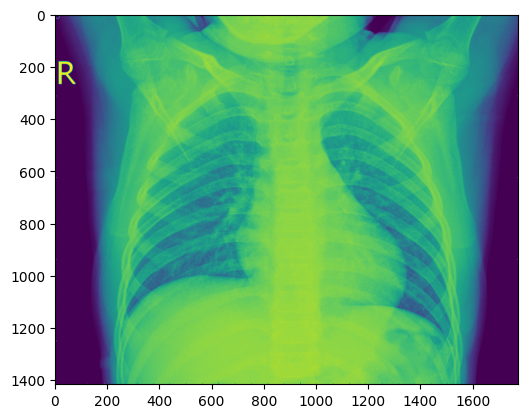

In [40]:
get_random_image("val","n")

2 ./data/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg


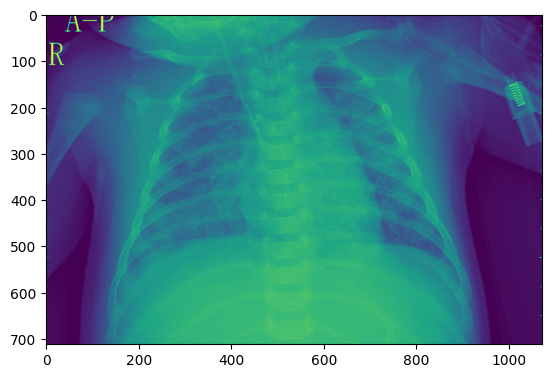

In [41]:
get_random_image("val","p")


In [45]:
from PIL import Image

# Replace 'path/to/your/image.jpg' with your actual image file path
image = Image.open('./data/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg')
print(image.format)
print(image.size)
print(image.mode)

JPEG
(1152, 664)
L


In [46]:
import PIL.Image

rgba_image=PIL.Image.open('./data/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg')
rgb_image=rgba_image.convert('RGB')

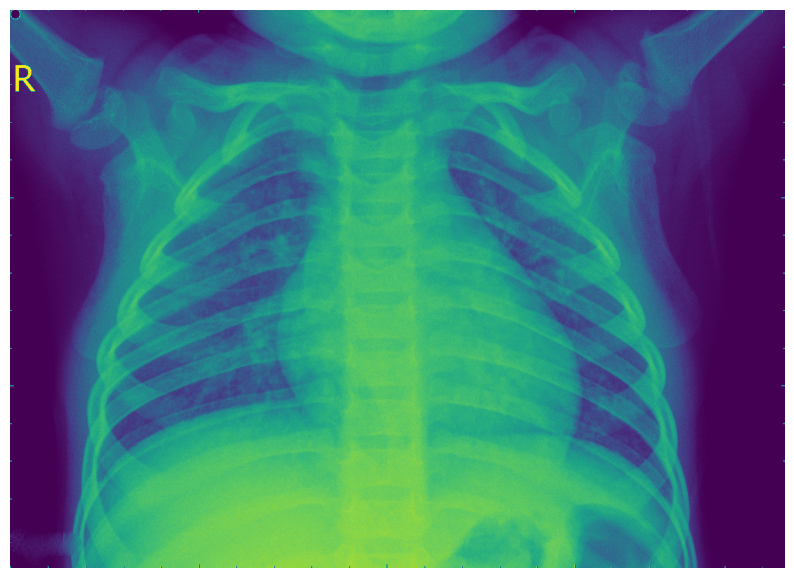

In [47]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Provide the correct path to your image file
# Replace with your actual image path
img = mpimg.imread('./data/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg')

# Display the image
plt.figure(figsize=(10,8))  # Optional: set figure size
imgplot = plt.imshow(img)
plt.axis('off')  # Optional: hide axes
plt.show()

In [51]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

folder=f'./data/chest_xray/train/*/*.jpeg'

counterPneu=0
counterNormal=0

img_paths=glob.glob(folder)

for i in img_paths:
    if "person" in i:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/train' + '/train_pneumonia' + str(counterPneu)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterPneu+=1
    else:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/train' + '/train_normal' + str(counterNormal)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterNormal+=1
        

Processed 3875 Pneumonia images and 1341 Normal images.


In [ ]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

folder=f'./data/chest_xray/test/*/*.jpeg'

counterPneu=0
counterNormal=0

img_paths=glob.glob(folder)

for i in img_paths:
    if "person" in i:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/test' + '/test_pneumonia' + str(counterPneu)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterPneu+=1
    else:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/test' + '/test_normal' + str(counterNormal)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterNormal+=1

In [52]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

folder=f'./data/chest_xray/val/*/*.jpeg'

counterPneu=0
counterNormal=0

img_paths=glob.glob(folder)

for i in img_paths:
    if "person" in i:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/val' + '/val_pneumonia' + str(counterPneu)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterPneu+=1
    else:
        full_size_image=Image.open(i)
        im=full_size_image.resize((224,224))
        plt.imsave(fname='./data/chest_xray/val' + '/val_normal' + str(counterNormal)+'.jpeg',arr=im,format='jpeg',cmap='gray')
        counterNormal+=1

In [54]:
import glob
import pandas as pd

folder=f'./data/chest_xray/*/*.jpeg'

category=[]
filenames=[]
condition_of_lung=[]

all_files=glob.glob(folder)

for filename in all_files:
    if "train" in filename:
        if "pneumonia" in filename:
            category.append("train")
            filenames.append(filename)
            condition_of_lung.append("pneumonia")
        elif "normal" in filename:
            category.append("train")
            filenames.append(filename)
            condition_of_lung.append("normal")
    elif "test" in filename:
        if "pneumonia" in filename:
            category.append("test")
            filenames.append(filename)
            condition_of_lung.append("pneumonia")
        elif "normal" in filename:
            category.append("test")
            filenames.append(filename)
            condition_of_lung.append("normal")
    elif "val" in filename:
        if "pneumonia" in filename:
            category.append("val")
            filenames.append(filename)
            condition_of_lung.append("pneumonia")
        elif "normal" in filename:
            category.append("val")
            filenames.append(filename)
            condition_of_lung.append("normal")

all_data_df=pd.DataFrame({"dataset type":category,"x-ray result":condition_of_lung,"filename":filenames})

print(all_data_df.head())

  dataset type x-ray result                                    filename
0         test       normal    ./data/chest_xray/test/test_normal0.jpeg
1         test       normal    ./data/chest_xray/test/test_normal1.jpeg
2         test       normal   ./data/chest_xray/test/test_normal10.jpeg
3         test       normal  ./data/chest_xray/test/test_normal100.jpeg
4         test       normal  ./data/chest_xray/test/test_normal101.jpeg


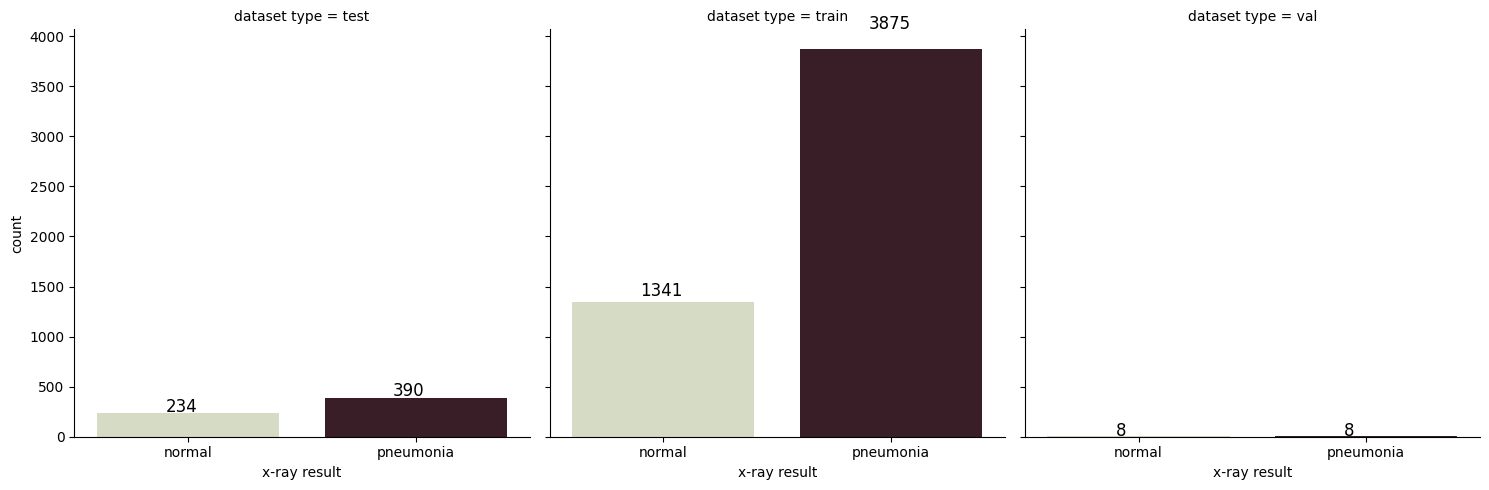

In [56]:
import seaborn as sns

# Use `hue` with the same variable as `x` and set `legend=False`
g = sns.catplot(
    x="x-ray result",  # Variable for the x-axis
    col="dataset type",  # Facet by dataset type (train, test, val)
    kind="count",  # Plot counts
    palette="ch:.55",  # Set color palette
    data=all_data_df,  # Data source
    hue="x-ray result",  # Assign `x` to `hue` to use `palette`
    legend=False  # Avoid duplicate legend
)

# Add annotations to the bars
for i in range(0, 3):
    ax = g.facet_axis(0, i)
    for p in ax.patches:
        ax.text(
            p.get_x() + 0.3,  # X position of the text
            p.get_height() * 1.05,  # Y position of the text (slightly above the bar)
            '{0:.0f}'.format(p.get_height()),  # Text to display (bar height)
            color='black',  # Text color
            rotation='horizontal',  # Text rotation
            size='large'  # Text size
        )

In [62]:
import glob
import pandas as pd
import os
train_folder='./data/chest_xray/train/*.jpeg'
train_df_lst=pd.DataFrame(columns=['labels','filename'],dtype=object)
train_imgs_path=glob.glob(train_folder)
counter=0
class_arg=''

for i in train_imgs_path:
    if "pneumonia" in i:
        class_arg=1
    else:
        class_arg=0
    train_df_lst.loc[counter]=[class_arg,os.path.basename(i)]
    counter+=1
print(train_df_lst.head())

   labels               filename
0       0     train_normal0.jpeg
1       0     train_normal1.jpeg
2       0    train_normal10.jpeg
3       0   train_normal100.jpeg
4       0  train_normal1000.jpeg


In [63]:
import glob
import pandas as pd
import os
test_folder='./data/chest_xray/test/*.jpeg'
test_df_lst=pd.DataFrame(columns=['labels','filename'],dtype=object)
test_imgs_path=glob.glob(test_folder)
counter=0
class_arg=''

for i in test_imgs_path:
    if "pneumonia" in i:
        class_arg=1
    else:
        class_arg=0
    test_df_lst.loc[counter]=[class_arg,os.path.basename(i)]
    counter+=1
print(test_df_lst.head())

   labels             filename
0       0    test_normal0.jpeg
1       0    test_normal1.jpeg
2       0   test_normal10.jpeg
3       0  test_normal100.jpeg
4       0  test_normal101.jpeg


In [64]:
def save_to_lst(df,prefix):
    return df[["labels","filename"]].to_csv(
    f"{prefix}.lst", sep='\t',index=True,header=False
    )

save_to_lst(train_df_lst.copy(),"train")
save_to_lst(test_df_lst.copy(),"test")

In [1]:
!pip install torch torchvision pandas pillow

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import os

In [3]:
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, directory, transform=None):
        self.dataframe = dataframe
        self.directory = directory
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.directory, self.dataframe.iloc[idx, 1])
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx, 0]

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
# Load .lst files
train_df = pd.read_csv("train.lst", sep='\t', header=None, names=["labels", "filename"])
test_df = pd.read_csv("test.lst", sep='\t', header=None, names=["labels", "filename"])

# Define directories
train_dir = "./data/chest_xray/train"
test_dir = "./data/chest_xray/test"

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize for pretrained models
])

# Create datasets
train_dataset = ChestXRayDataset(train_df, train_dir, transform=transform)
test_dataset = ChestXRayDataset(test_df, test_dir, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [83]:
# Check the labels in the training data
print(train_df["labels"].value_counts())

# Check the labels in the test data
print(test_df["labels"].value_counts())

1    3875
0    1341
Name: labels, dtype: int64
1    390
0    234
Name: labels, dtype: int64


In [5]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load a pre-trained ResNet18 model
model = models.resnet18(pretrained=True)

# Modify the final fully connected layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)

# Move the model to the appropriate device
model = model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


Using device: cuda


100%|██████████| 44.7M/44.7M [00:03<00:00, 13.1MB/s]


In [6]:
# Define the loss function (BCEWithLogitsLoss)
criterion = nn.BCEWithLogitsLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels.float().view(-1, 1))

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 10 == 9:  # Print every 10 batches
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {running_loss/10:.4f}")
            running_loss = 0.0

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [8]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels.float().view(-1, 1)).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 86.86%


In [9]:
# Save the model locally
torch.save(model.state_dict(), "local_image_classifier_model.pth")